### Explore the `crimes.csv` dataset and use your findings to answer the following questions:

- Which hour has the highest frequency of crimes?
      Store as an integer variable called `peak_crime_hour`.
  
- Which area has the largest frequency of night crimes (crimes committed between 10pm and 3:59am)?
    Save as a string variable called `peak_night_crime_location`.

- Identify the number of crimes committed against victims of different age groups.
    Save as a pandas Series called victim_ages, with age group labels `"0-17"`, `"18-25"`, `"26-34"`, `"35-44"`, `"45-54"`, `"55-64"`, and `"65+"` as the index and the frequency of crimes as the values.

### The Data

They have provided you with a single dataset to use. A summary and preview are provided below.

It is a modified version of the original data, which is publicly available from Los Angeles Open Data.

### crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

In [2]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
crimes = pd.read_csv("crimes.csv", dtype={"TIME OCC": str})
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


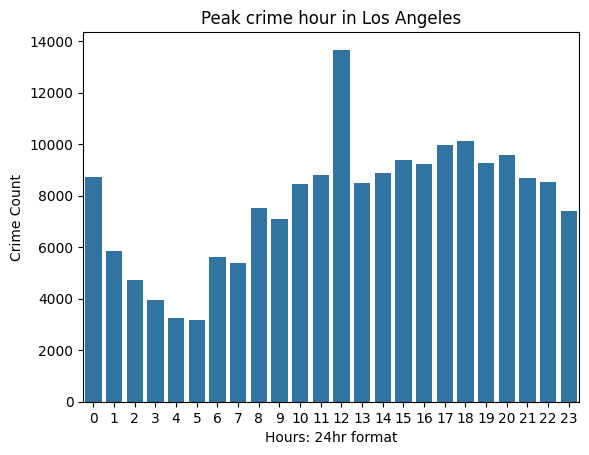

In [3]:
# Finding the frequencies of crimes by the hour of occurrence
''' 
Steps:
1. Extract hours and store it in a new column.
2. Plot the frequenty using sns.countplot()
3. Lastly, create variable peak_crime_hour and assign the top value from the plot (idxmax value using groupby() ).
'''

crimes["HOUR OCC"] = crimes["TIME OCC"].str[:2].astype(int)

sns.countplot(data= crimes, x="HOUR OCC")
plt.title("Peak crime hour in Los Angeles")
plt.xlabel("Hours: 24hr format")
plt.ylabel("Crime Count")
plt.show()

In [4]:
peak_crime_hour = crimes.groupby("HOUR OCC").size().idxmax()
print("The Hour for peak crime is : ", peak_crime_hour)

The Hour for peak crime is :  12


In [33]:
# Areas with the largest frequency of night crimes
'''
1. Use boolean subset and create a new dataframe night_crimes
2. Count the frequency of the areas where crimes is max at night
3. Print the frequency
'''
night_crimes = crimes[crimes["HOUR OCC"].isin([22, 23, 0, 1, 2, 3])]

peak_night_crime_location = night_crimes["AREA NAME"].value_counts().idxmax()
print("The location for peck crimes at night is: ", peak_night_crime_location)


The location for peck crimes at night is:  Central


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
 [Text(0, 0, '77th Street'),
  Text(1, 0, 'Devonshire'),
  Text(2, 0, 'Newton'),
  Text(3, 0, 'Foothill'),
  Text(4, 0, 'Wilshire'),
  Text(5, 0, 'Central'),
  Text(6, 0, 'Van Nuys'),
  Text(7, 0, 'Topanga'),
  Text(8, 0, 'Southeast'),
  Text(9, 0, 'West Valley'),
  Text(10, 0, 'Mission'),
  Text(11, 0, 'Pacific'),
  Text(12, 0, 'Olympic'),
  Text(13, 0, 'Hollywood'),
  Text(14, 0, 'Southwest'),
  Text(15, 0, 'Hollenbeck'),
  Text(16, 0, 'Northeast'),
  Text(17, 0, 'Harbor'),
  Text(18, 0, 'Rampart'),
  Text(19, 0, 'West LA'),
  Text(20, 0, 'N Hollywood')])

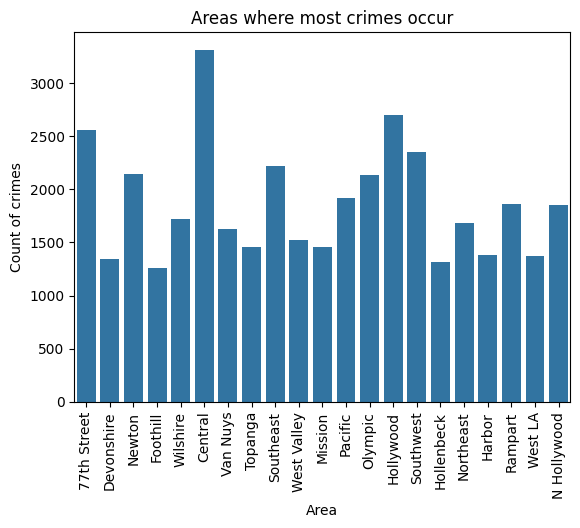

In [34]:
# Plotting the area where most crime occur
sns.countplot(data= crimes, x=night_crimes["AREA NAME"])
plt.title("Areas where most crimes occur")
plt.xlabel("Area")
plt.ylabel("Count of crimes")
plt.xticks(rotation=90)

In [62]:
# The number of crimes committed against victims of different age groups

# Remove invalid (negative) ages
crimes = crimes[crimes["Vict Age"] >= 0]

# Define bins and labels
age_bins = [0, 17, 25, 34, 44, 54, 64, np.inf]
age_labels = ["0-17", "18-25", "26-34", "35-44", "45-54", "55-64", "65+"]

# Split ages into groups
age_groups = pd.cut(crimes["Vict Age"], bins=age_bins, labels=age_labels)

In [63]:
victim_ages = age_groups.value_counts().sort_index()
print(victim_ages)

Vict Age
0-17      4528
18-25    28291
26-34    47470
35-44    42157
45-54    28353
55-64    20169
65+      14747
Name: count, dtype: int64


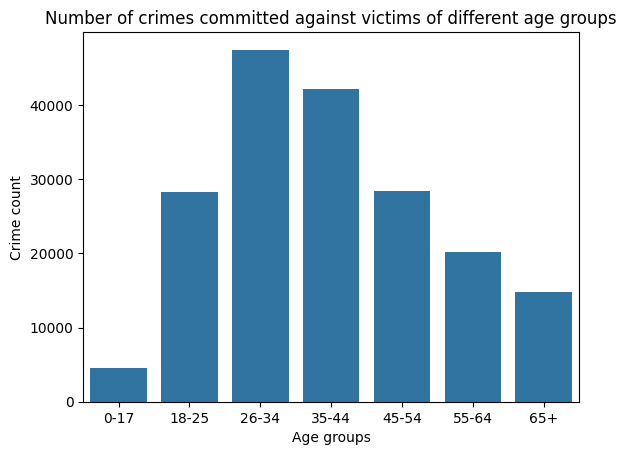

In [64]:
sns.countplot(data= crimes, x="Age_Bracket")
plt.title("Number of crimes committed against victims of different age groups")
plt.xlabel("Age groups")
plt.ylabel("Crime count")
plt.show()